# Looping Graph — Higher / Lower Guessing Game

A binary-search guesser with 4 functional nodes: `initialize`, `setup`, `make_guess`, `give_hint` — looping until correct or 7 attempts.

In [1]:
from typing import TypedDict, Literal
import random

from langgraph.graph import StateGraph, START, END
from IPython.display import display, Markdown, Image

In [2]:
class State(TypedDict):
    target: int
    lower: int
    upper: int
    guess: int
    hint: str
    attempts: int

In [3]:
def initialize(state: State) -> State:
    return {"hint": "", "attempts": 0}


def setup(state: State) -> State:
    return {"target": random.randint(1, 20), "lower": 1, "upper": 20}


def make_guess(state: State) -> State:
    lower = state["lower"]
    upper = state["upper"]
    if state["hint"] == "higher":
        lower = state["guess"] + 1
    elif state["hint"] == "lower":
        upper = state["guess"] - 1
    guess = (lower + upper) // 2
    return {"guess": guess, "lower": lower, "upper": upper, "attempts": state["attempts"] + 1}


def give_hint(state: State) -> State:
    g, t = state["guess"], state["target"]
    return {"hint": "correct" if g == t else ("higher" if g < t else "lower")}

In [4]:
def router(state: State) -> Literal["make_guess", "__end__"]:
    if state["hint"] == "correct" or state["attempts"] >= 7:
        return "__end__"
    return "make_guess"

In [5]:
builder = StateGraph(State)
builder.add_node("initialize", initialize)
builder.add_node("setup", setup)
builder.add_node("make_guess", make_guess)
builder.add_node("give_hint", give_hint)

builder.add_edge(START, "initialize")
builder.add_edge("initialize", "setup")
builder.add_edge("setup", "make_guess")
builder.add_edge("make_guess", "give_hint")
builder.add_conditional_edges("give_hint", router)

app = builder.compile()

In [6]:
display(Markdown(f"```mermaid\n{app.get_graph().draw_mermaid()}\n```"))

```mermaid
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	initialize(initialize)
	setup(setup)
	make_guess(make_guess)
	give_hint(give_hint)
	__end__([<p>__end__</p>]):::last
	__start__ --> initialize;
	give_hint -.-> __end__;
	give_hint -.-> make_guess;
	initialize --> setup;
	make_guess --> give_hint;
	setup --> make_guess;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

```

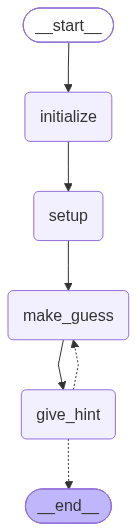

In [7]:
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [8]:
result = app.invoke({})
target = result["target"]
outcome = "correct" if result["hint"] == "correct" else "failed"
print(f"Target: {target}, {outcome} in {result['attempts']} attempt(s), last guess: {result['guess']}")

Target: 20, correct in 5 attempt(s), last guess: 20


In [9]:
for i in range(5):
    r = app.invoke({})
    print(f"Round {i+1}: target={r['target']}, hint={r['hint']}, attempts={r['attempts']}")

Round 1: target=16, hint=correct, attempts=4
Round 2: target=10, hint=correct, attempts=1
Round 3: target=12, hint=correct, attempts=3
Round 4: target=16, hint=correct, attempts=4
Round 5: target=2, hint=correct, attempts=3
